<a href="https://colab.research.google.com/github/flynnava/Global-Poverty-and-Inequality-Trends/blob/main/Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research Question:
How did the 2008 Global Financial Crisis and the COVID-19 pandemic influence the relationship between income inequality and poverty across countries?

(4877, 108)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4877 entries, 0 to 4876
Columns: 108 entries, country to p50_p10_ratio
dtypes: float64(103), int64(2), object(3)
memory usage: 4.0+ MB
Duplicates: 0
(4049, 108)
['country', 'year', 'reporting_level', 'welfare_type', 'ppp_version', 'survey_year', 'survey_comparability', 'headcount_ratio_international_povline', 'headcount_ratio_lower_mid_income_povline', 'headcount_ratio_upper_mid_income_povline', 'headcount_ratio_100', 'headcount_ratio_1000', 'headcount_ratio_2000', 'headcount_ratio_3000', 'headcount_ratio_4000', 'headcount_ratio_40_median', 'headcount_ratio_50_median', 'headcount_ratio_60_median', 'headcount_international_povline', 'headcount_lower_mid_income_povline', 'headcount_upper_mid_income_povline', 'headcount_100', 'headcount_1000', 'headcount_2000', 'headcount_3000', 'headcount_4000', 'headcount_40_median', 'headcount_50_median', 'headcount_60_median', 'avg_shortfall_international_povline', 'avg_shortfall_lower_mid_

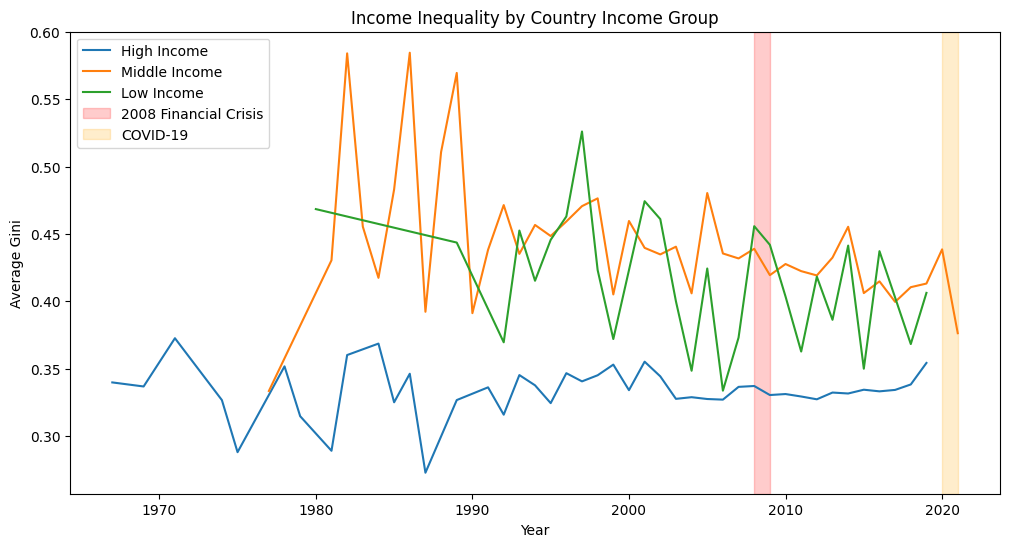

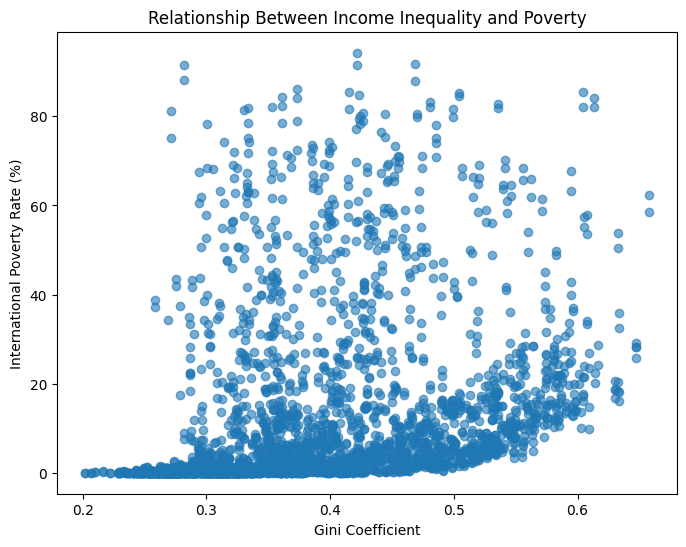

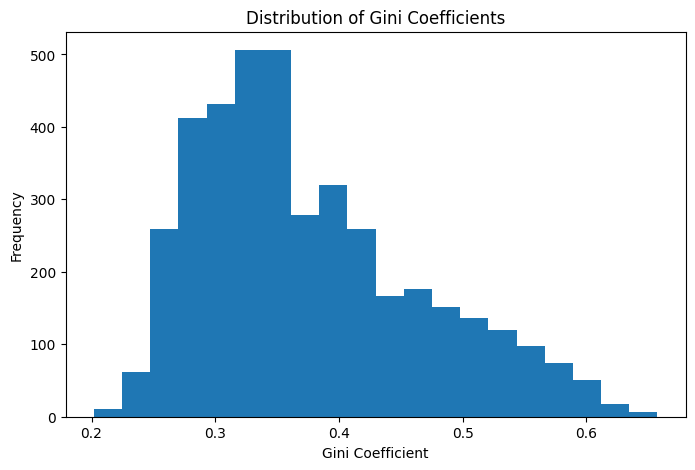

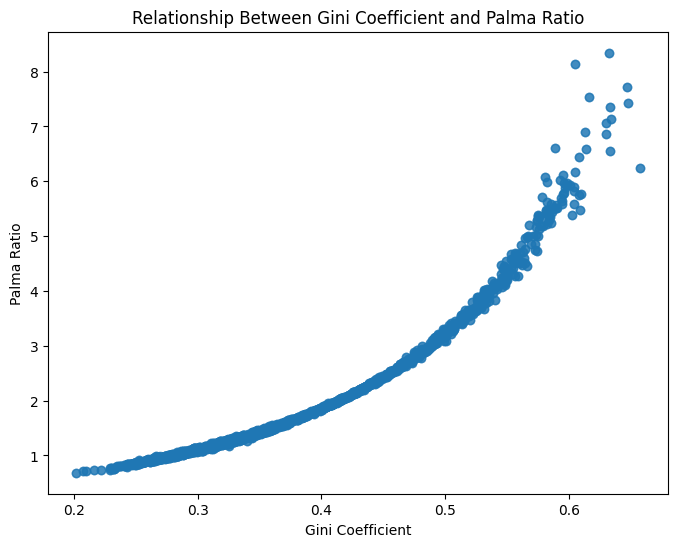

In [6]:
import pandas as pd
import numpy as np

# Country Income Groups according to World Bank
# --------------

# High Income countries
high_income = [
    "United States",
    "Canada",
    "Germany",
    "United Kingdom",
    "France",
    "Japan",
    "Australia",
    "South Korea",
    "Sweden",
    "Switzerland"
]

# Middle Income Countries
middle_income = [
    "Brazil",
    "China",
    "Mexico",
    "South Africa",
    "Turkey",
    "Indonesia",
    "India",
    "Philippines",
    "Vietnam",
    "Egypt"
]

# Low Income Countries
low_income = [
    "Burundi",
    "Chad",
    "Democratic Republic of the Congo",
    "Ethiopia",
    "Madagascar",
    "Malawi",
    "Mozambique",
    "Niger",
    "Sierra Leone",
    "Uganda"
]

#-----------------

# Load dataset
df = pd.read_csv("poverty_original.csv")

# Create a copy
clean_df = df.copy()

# Inspects the data
print(clean_df.shape)
clean_df.head()
clean_df.info()
clean_df.describe()

# Check for missing values
clean_df.isnull().sum().sort_values(ascending=False)

# Removes duplicate rows
print("Duplicates:", clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()

# Keeps only country level observations
clean_df = clean_df[
    clean_df["reporting_level"] == "national"
]

print(clean_df.shape)

# Check column names
print(clean_df.columns.tolist())

# Converts data types
clean_df["year"] = clean_df["year"].astype(int)
categorical = [
    "country",
    "reporting_level",
    "welfare_type"
]
for col in categorical:
    clean_df[col] = clean_df[col].astype("category")

# Keep only variables I need
research_df = clean_df[[
    "country",
    "year",
    "gini",
    "palma_ratio",
    "headcount_ratio_international_povline",
    "headcount_ratio_lower_mid_income_povline",
    "headcount_ratio_upper_mid_income_povline",
    "mean",
    "median",
    "welfare_type"
]]
# Split data into income groups
high_df = research_df[research_df["country"].isin(high_income)]
middle_df = research_df[research_df["country"].isin(middle_income)]
low_df = research_df[research_df["country"].isin(low_income)]

# Check for impossible values
research_df.describe()

# Save cleaned data
research_df.to_csv(
    "poverty_clean.csv",
    index=False
)


# Visulization
import matplotlib.pyplot as plt

# Average by year for each income group
high_yearly = high_df.groupby("year")[["gini"]].mean()
middle_yearly = middle_df.groupby("year")[["gini"]].mean()
low_yearly = low_df.groupby("year")[["gini"]].mean()

plt.figure(figsize=(12,6))

plt.plot(high_yearly.index,
         high_yearly["gini"],
         label="High Income")

plt.plot(middle_yearly.index,
         middle_yearly["gini"],
         label="Middle Income")

plt.plot(low_yearly.index,
         low_yearly["gini"],
         label="Low Income")

plt.axvspan(2008, 2009,
            color="red",
            alpha=0.2,
            label="2008 Financial Crisis")

plt.axvspan(2020, 2021,
            color="orange",
            alpha=0.2,
            label="COVID-19")

plt.xlabel("Year")
plt.ylabel("Average Gini")
plt.title("Income Inequality by Country Income Group")

plt.legend()
plt.show()
# Scatter Plot: Gini vs. Poverty Rate
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(clean_df["gini"],
            clean_df["headcount_ratio_international_povline"],
            alpha=0.6)

plt.xlabel("Gini Coefficient")
plt.ylabel("International Poverty Rate (%)")
plt.title("Relationship Between Income Inequality and Poverty")

plt.show()

# Histogram of Gini coefficient
plt.figure(figsize=(8,5))

plt.hist(clean_df["gini"], bins=20)

plt.xlabel("Gini Coefficient")
plt.ylabel("Frequency")
plt.title("Distribution of Gini Coefficients")

plt.show()

#Scatter Plot: Gini vs. Palma Ratio
plt.figure(figsize=(8,6))

plt.scatter(clean_df["gini"],
            clean_df["palma_ratio"],
            alpha=0.6)

plt.xlabel("Gini Coefficient")
plt.ylabel("Palma Ratio")
plt.title("Relationship Between Gini Coefficient and Palma Ratio")

plt.show()

Data Cleaning
---



The dataset was cleaned by inspecting its structure, checking for duplicate records, and verifying the data types of each variable. No duplicate records were found, and the dataset was filtered to include only national-level observations by removing regional aggregate data, ensuring the analysis focused on individual countries. Additional checks for missing values and invalid observations will be performed on the variables used for the analysis.

# Exploratory Data Analysis and Visulization

To begin exploring the relationship between income inequality and poverty, a scatter plot will be created using the Gini coefficient as the independent variable and the International Poverty Rate (Headcount Ratio at the International Poverty Line) as the dependent variable. This visualization will help identify whether countries with higher income inequality also tend to have higher poverty rates. In addition, a line graph showing the average Gini coefficient and average poverty rate over time will be used to observe changes before, during, and after the 2008–2009 Global Financial Crisis and the 2020–2021 COVID-19 pandemic.

# Expected Inference

The scatter plot will help determine whether a positive relationship exists between income inequality and poverty, while the line graph will show whether major global crises coincide with changes in these indicators over time. Together, these visualizations will provide an initial understanding of how global crises may have influenced the relationship between income inequality and poverty across countries before more advanced statistical analyses are performed.